In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from imblearn.pipeline import Pipeline
from datetime import datetime
from timeit import default_timer as timer

from sklearn.preprocessing import  MinMaxScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV,StratifiedKFold, RandomizedSearchCV
from sklearn.svm import SVC, OneClassSVM
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (accuracy_score, recall_score,f1_score,RocCurveDisplay,roc_auc_score, \
PrecisionRecallDisplay, precision_score, precision_recall_curve, classification_report, ConfusionMatrixDisplay, confusion_matrix)

from sklearn.metrics import auc # Import auc for AUPRC
from sklearn.metrics import make_scorer, recall_score

**Load the saved data from main notebook pkl files**

In [ ]:
import pickle
import os

from google.colab import drive
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/saved_model_components_backup'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the train/test splits
with open(os.path.join(save_dir, 'X_train.pkl'), 'rb') as f:
    loaded_X_train = pickle.load(f)
with open(os.path.join(save_dir, 'X_test.pkl'), 'rb') as f:
    loaded_X_test = pickle.load(f)
with open(os.path.join(save_dir, 'y_train.pkl'), 'rb') as f:
    loaded_y_train = pickle.load(f)
with open(os.path.join(save_dir, 'y_test.pkl'), 'rb') as f:
    loaded_y_test = pickle.load(f)
print("Loaded train/test data.")

# Load the dictionary of best models
with open(os.path.join(save_dir, 'best_models.pkl'), 'rb') as f:
    loaded_best_models = pickle.load(f)
print(f"Loaded best models from {os.path.join(save_dir, 'best_models.pkl')}")

print("\nVerification of loaded data types:")

print(f"Type of loaded_X_train: {type(loaded_X_train)}")
print(f"Type of loaded_best_models: {type(loaded_best_models)}")


Loaded train/test data.
Loaded best models from /content/drive/MyDrive/saved_model_components_backup/best_models.pkl

Verification of loaded data types:
Type of loaded_X_train: <class 'pandas.core.frame.DataFrame'>
Type of loaded_best_models: <class 'dict'>


In [ ]:
# Load the train/test splits
with open(os.path.join(save_dir, 'X_train.pkl'), 'rb') as f:
    loaded_X_train = pickle.load(f)
with open(os.path.join(save_dir, 'X_test.pkl'), 'rb') as f:
    loaded_X_test = pickle.load(f)
with open(os.path.join(save_dir, 'y_train.pkl'), 'rb') as f:
    loaded_y_train = pickle.load(f)
with open(os.path.join(save_dir, 'y_test.pkl'), 'rb') as f:
    loaded_y_test = pickle.load(f)
print("Loaded train/test data.")

# Load the dictionary of best models
with open(os.path.join(save_dir, 'best_models.pkl'), 'rb') as f:
    loaded_best_models = pickle.load(f)
print(f"Loaded best models from {os.path.join(save_dir, 'best_models.pkl')}")

print("\nVerification of loaded data types:")

print(f"Type of loaded_X_train: {type(loaded_X_train)}")
print(f"Type of loaded_best_models: {type(loaded_best_models)}")


Loaded train/test data.
Loaded best models from /content/drive/MyDrive/saved_model_components_backup/best_models.pkl

Verification of loaded data types:
Type of loaded_X_train: <class 'pandas.core.frame.DataFrame'>
Type of loaded_best_models: <class 'dict'>


In [ ]:
X_train=loaded_X_train
X_test=loaded_X_test
y_train=loaded_y_train
y_test=loaded_y_test
X=pd.concat([X_train,X_test])
y=pd.concat([y_train,y_test])

X.shape,y.shape

((283726, 30), (283726,))

### Neural network Multi layer perceptron (Supervised)

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import RocCurveDisplay
from timeit import default_timer as timer

# Create a pipeline and use scaled data here
mlp=MLPClassifier(max_iter=1000, batch_size=32, early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42)
mlpc_pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    # add SMOTE
    #('smote', BorderlineSMOTE(random_state=42)),
     #  stop when optimal perf is reaached and stops overfitting by following an L2 kind of regularization , also # saves computational time .
    ('mlpc',mlp)
])

start = timer()
print(f"Training MLP Classifier...at ", datetime.now(),  " UTC")
mlpc_pipe.fit(X_train, y_train)
# print time talken
print(f"Training time: {timer()-start}")

Training MLP Classifier...at  2026-06-02 13:45:13.532928  UTC
Training time: 171.2990627729996


In [ ]:
y_preds_mlp= mlpc_pipe.predict(X_test)
#mlp_initial_accuracy = accuracy_score(y_test, y_preds_mlp) # Renamed variable to avoid shadowing the function

# Print recall , f1-score, precision
#print(f"Accuracy: {mlp_initial_accuracy}") # Using the renamed variable
print(f"Precision: {precision_score(y_test, y_preds_mlp)}")
print(f"Recall: {recall_score(y_test, y_preds_mlp)}")
print(f"F1-Score: {f1_score(y_test, y_preds_mlp)}")

Precision: 0.8588235294117647
Recall: 0.7684210526315789
F1-Score: 0.8111111111111111


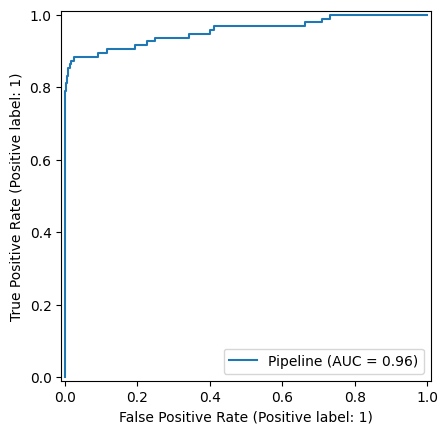

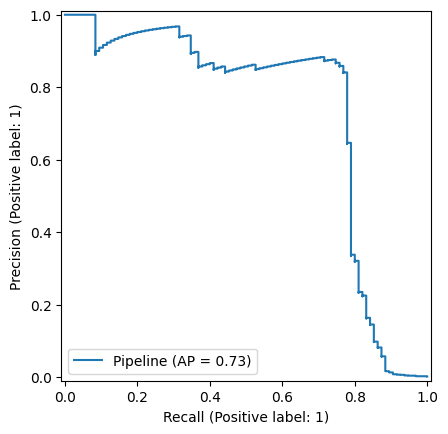

In [ ]:
# Plot ROC AUC and AUPRC
RocCurveDisplay.from_estimator(mlpc_pipe, X_test, y_test)
plt.show()
PrecisionRecallDisplay.from_estimator(mlpc_pipe, X_test, y_test)
plt.show()

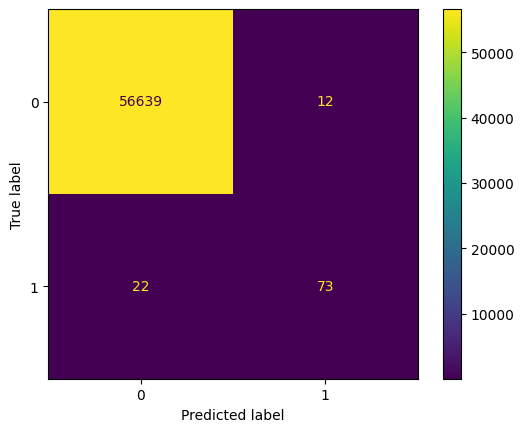

In [ ]:
# Plot confusion matrix
ConfusionMatrixDisplay.from_estimator(mlpc_pipe, X_test, y_test)
plt.show()

In [ ]:
mlpc_pipe.get_params()

{'memory': None,
 'steps': [('scaler', MinMaxScaler()),
  ('mlpc',
   MLPClassifier(batch_size=32, early_stopping=True, hidden_layer_sizes=(64, 32),
                 max_iter=1000, random_state=42))],
 'transform_input': None,
 'verbose': False,
 'scaler': MinMaxScaler(),
 'mlpc': MLPClassifier(batch_size=32, early_stopping=True, hidden_layer_sizes=(64, 32),
               max_iter=1000, random_state=42),
 'scaler__clip': False,
 'scaler__copy': True,
 'scaler__feature_range': (0, 1),
 'mlpc__activation': 'relu',
 'mlpc__alpha': 0.0001,
 'mlpc__batch_size': 32,
 'mlpc__beta_1': 0.9,
 'mlpc__beta_2': 0.999,
 'mlpc__early_stopping': True,
 'mlpc__epsilon': 1e-08,
 'mlpc__hidden_layer_sizes': (64, 32),
 'mlpc__learning_rate': 'constant',
 'mlpc__learning_rate_init': 0.001,
 'mlpc__max_fun': 15000,
 'mlpc__max_iter': 1000,
 'mlpc__momentum': 0.9,
 'mlpc__n_iter_no_change': 10,
 'mlpc__nesterovs_momentum': True,
 'mlpc__power_t': 0.5,
 'mlpc__random_state': 42,
 'mlpc__shuffle': True,
 'mlp

Quite good result in terms of FPs reduced significantly but need to reduce FNs as well.

In [ ]:
# Do grid search for MLP
params={
    'hidden_layer_sizes': [(64,32),(128, 64), (256,128)],
    'activation': ['relu'], # activation function for the  hidden layer
    'solver': ['adam'],
    'alpha': [0.00005,0.00008],
    'learning_rate': ['constant']
}

In [ ]:
# calculate training time as well
start_time = timer()
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) #  K-Fold cross validation
grids_mlp = RandomizedSearchCV(MLPClassifier(max_iter=1000, batch_size=32,
                                             early_stopping=True),
                                params, scoring='recall', cv=cv, n_jobs=-1, n_iter=6) # limiting the iterations to match the combination of params
print(f"Tuning MLP using Randomized CV...at ", datetime.now(),  " UTC")
grids_mlp.fit(X_train, y_train)
train_time_model = timer()- start_time
# Print the time
print(f"Training time: {train_time_model}")


Tuning MLP using Randomized CV...at  2026-06-02 17:24:34.575091  UTC


KeyboardInterrupt: 

In [ ]:
y_preds_mlp_gs = grids_mlp.best_estimator_.predict(X_test)

print(f"Best parameters: {grids_mlp.best_params_}")
print(f"Best score: {grids_mlp.best_score_}")
print(f"Train time: {train_time_model}")


In [ ]:
y_preds_mlp_gs = grids_mlp.best_estimator_.predict(X_test)

print(f"Best parameters: {grids_mlp.best_params_}")
print(f"Best score: {grids_mlp.best_score_}")
print(f"Train time: {train_time_model}")


Best parameters: {'solver': 'adam', 'learning_rate': 'constant', 'hidden_layer_sizes': (128, 64), 'alpha': 0.0001, 'activation': 'relu'}
Best score: 0.7857142857142857
Train time: 967.276031772999


In [ ]:
# Plot precision , recall , F1- score and ROC AUC and AUPRC for best estimators
# mlp_accuracy_score  = accuracy_score(y_test, y_preds_mlp_gs)
# print(f"Accuracy: {accuracy}")
print(f"Precision: {precision_score(y_test, y_preds_mlp_gs)}")
print(f"Recall: {recall_score(y_test, y_preds_mlp_gs)}")
print(f"F1-Score: {f1_score(y_test, y_preds_mlp_gs)}")

cm = confusion_matrix(y_test, y_preds_mlp_gs)
print("Confusion Matrix:")
print(cm)
# Plot the PRC and ROC
RocCurveDisplay.from_estimator(grids_mlp, X_test, y_test)
plt.show()
PrecisionRecallDisplay.from_estimator(grids_mlp, X_test, y_test)
plt.show()

Precision: 0.8875
Recall: 0.7473684210526316
F1-Score: 0.8114285714285714
Confusion Matrix:
[[56642     9]
 [   24    71]]


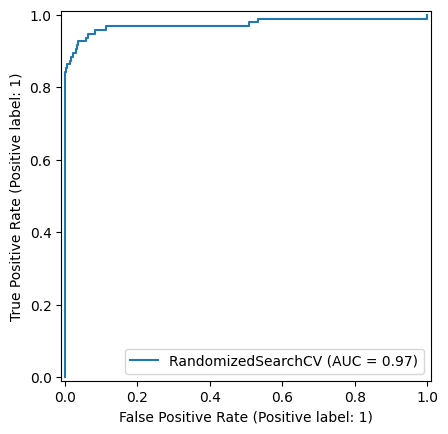

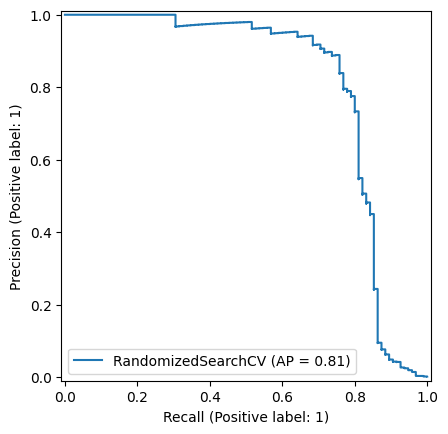

In [ ]:
# Plot precision , recall , F1- score and ROC AUC and AUPRC for best estimators
# mlp_accuracy_score  = accuracy_score(y_test, y_preds_mlp_gs)
# print(f"Accuracy: {accuracy}")
print(f"Precision: {precision_score(y_test, y_preds_mlp_gs)}")
print(f"Recall: {recall_score(y_test, y_preds_mlp_gs)}")
print(f"F1-Score: {f1_score(y_test, y_preds_mlp_gs)}")

cm = confusion_matrix(y_test, y_preds_mlp_gs)
print("Confusion Matrix:")
print(cm)
# Plot the PRC and ROC
RocCurveDisplay.from_estimator(grids_mlp, X_test, y_test)
plt.show()
PrecisionRecallDisplay.from_estimator(grids_mlp, X_test, y_test)
plt.show()

In [ ]:
grids_mlp.best_estimator_.get_params()

### Addressing Class Imbalance with Borderline SMOTE

Given the `MLPClassifier` does not directly support `class_weight` in its constructor, and to address the class imbalance effectively, we will use **Borderline SMOTE** for oversampling the minority class. Borderline SMOTE is a variant of SMOTE that generates synthetic samples only for the minority class instances that are near the decision boundary, which can be more effective than standard SMOTE in some cases.

We will integrate Borderline SMOTE into a `Pipeline` from `imblearn` (scikit-learn-contrib) along with the `MLPClassifier`. This allows us to apply the oversampling strategy only on the training folds during cross-validation, preventing data leakage. Then, we will use `RandomizedSearchCV` to tune both the SMOTE parameters and the MLPClassifier parameters simultaneously.

In [ ]:
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.pipeline import Pipeline

# pipeline using Borderline SMOTE
mlp_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),# add scaler
#    ('smote', BorderlineSMOTE(random_state=42)),
    ('mlp', MLPClassifier(max_iter=1000, batch_size=32, early_stopping=True, random_state=42,verbose=1))
])

param_distributions_smote_mlp = {
    'mlp__hidden_layer_sizes': [(128, 64), (256, 128)],
    'mlp__activation': ['relu'],
    'mlp__solver': ['adam',],
    'mlp__alpha': [0.00005, 0.001],
    'mlp__learning_rate': ['constant']
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

start_time = timer()
print(f"Tuning MLP with Borderline SMOTE using RandomizedSearchCV...at ", datetime.now(), " UTC")

grids_mlp_smote = RandomizedSearchCV(mlp_pipeline,param_distributions=param_distributions_smote_mlp,scoring='recall',
  cv=cv,n_jobs=-1,n_iter=4,random_state=42) # Number of iters ceiled at grid search combinations

grids_mlp_smote.fit(X_train, y_train)
train_time_smote_mlp = timer() - start_time

y_preds_mlp_smote = grids_mlp_smote.best_estimator_.predict(X_test)

print(f"\nBest parameters (Borderline SMOTE + MLP): {grids_mlp_smote.best_params_}")
print(f"Best score (Borderline SMOTE + MLP): {grids_mlp_smote.best_score_}")
print(f"Train time (Borderline SMOTE + MLP): {train_time_smote_mlp}")

# Evaluate the SMOTE-enhanced model
accuracy_smote_mlp = accuracy_score(y_test, y_preds_mlp_smote)
precision_smote_mlp = precision_score(y_test, y_preds_mlp_smote)
recall_smote_mlp = recall_score(y_test, y_preds_mlp_smote)
f1_smote_mlp = f1_score(y_test, y_preds_mlp_smote)

print(f"\nTest Metrics for Borderline SMOTE + MLP Model:")
print(f"Accuracy: {accuracy_smote_mlp:.4f}")
print(f"Precision: {precision_smote_mlp:.4f}")
print(f"Recall: {recall_smote_mlp:.4f}")
print(f"F1-Score: {f1_smote_mlp:.4f}")

cm_smote_mlp = confusion_matrix(y_test, y_preds_mlp_smote)
print("\nConfusion Matrix (Borderline SMOTE + MLP):")
print(cm_smote_mlp)

# Plot the PRC and ROC for the SMOTE-enhanced model
RocCurveDisplay.from_estimator(grids_mlp_smote.best_estimator_, X_test, y_test)
plt.title('ROC Curve - Borderline SMOTE + MLP')
plt.show()
PrecisionRecallDisplay.from_estimator(grids_mlp_smote.best_estimator_, X_test, y_test)
plt.title('Precision-Recall Curve - Borderline SMOTE + MLP')
plt.show()

Tuning MLP with Borderline SMOTE using RandomizedSearchCV...at  2026-06-02 19:55:39.976192  UTC


KeyboardInterrupt: 

# Neural Network Multi-layer Perceptron (Supervised) with Keras and TensorFlow

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Apply both SMOTE and scale the data

Original training samples: 226980
Resampled training samples: 453204
Training Keras MLP with SMOTE...at  2026-06-02 14:16:57.895561  UTC


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
14163/14163 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - auc_prc: 0.9984 - loss: 0.0387 - precision: 0.9897 - recall: 0.9857 - val_auc_prc: 0.5901 - val_loss: 0.0183 - val_precision: 0.2524 - val_recall: 0.8316
Epoch 2/50
14163/14163 ━━━━━━━━━━━━━━━━━━━━ 52s 4ms/step - auc_prc: 0.9990 - loss: 0.0226 - precision: 0.9923 - recall: 0.9932 - val_auc_prc: 0.6372 - val_loss: 0.0133 - val_precision: 0.3407 - val_recall: 0.8105
Epoch 3/50
14163/14163 ━━━━━━━━━━━━━━━━━━━━ 86s 6ms/step - auc_prc: 0.9991 - loss: 0.0198 - precision: 0.9933 - recall: 0.9944 - val_auc_prc: 0.6101 - val_loss: 0.0196 - val_precision: 0.1916 - val_recall: 0.8211
Epoch 4/50
14163/14163 ━━━━━━━━━━━━━━━━━━━━ 109s 4ms/step - auc_prc: 0.9990 - loss: 0.0182 - precision: 0.9938 - recall: 0.9947 - val_auc_prc: 0.5808 - val_loss: 0.0130 - val_precision: 0.3347 - val_recall: 0.8316
Epoch 5/50
14163/14163 ━━━━━━━━━━━━━━━━━━━━ 53s 4ms/step - auc_prc: 0.9991 - loss: 0.0165 - precision: 0.9943 - recall: 0.9953 - val_auc_prc: 0.647

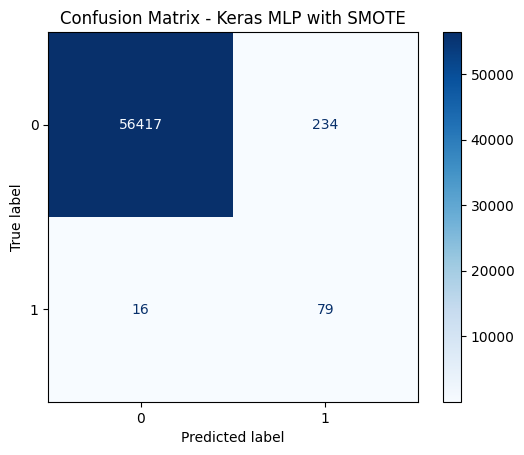

In [ ]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = BorderlineSMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(f"Original training samples: {len(X_train)}")
print(f"Resampled training samples: {len(X_train_resampled)}")

# Build and compile
model = Sequential([ # taking 128,64 as standard  - computers love powers of 2
    Dense(128, activation='relu', input_shape=(X_train_resampled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy', #  as it is a sigmoid output,  0,1
              metrics=[
                  tf.keras.metrics.Recall(name='recall'),
                  tf.keras.metrics.Precision(name='precision'),
                  # prioritize AU PRC
                  tf.keras.metrics.AUC(name='auc_prc', curve='PR'),
              ])

# Define Early Stopping callback- to avoid long training runs
early_stopping_callback = EarlyStopping(
    monitor='val_recall', # Monitor validation recall obviously for fraud detection, this is our main aim .
    patience=8,          # Number of epochs with no improvement after which training will be stopped.
    restore_best_weights=True, # Restore model weights from the epoch with the best value of the monitored quantity.
    mode='max',           # For recall, we want to maximize it
    verbose=1 # having the logs helps visulaize the whole process
)

print(f"Training Keras MLP with SMOTE...at ", datetime.now(),  " UTC")
mod_history = model.fit(X_train_resampled, y_train_resampled,
                        epochs=50, # Increased epochs since early stopping is used with patienc of 8
                        batch_size=32,
                        validation_data=(X_test_scaled, y_test),  # we can use the entire test data for validation set as wel
                        callbacks=[early_stopping_callback],
                        verbose=1)

# Evaluate the model on the test set
print("\nEvaluating Keras MLP on test data...")
loss, recall,precision, auc_prc = model.evaluate(X_test_scaled, y_test, verbose=0)



Visualizing Training and Validation Loss VS Accuracy



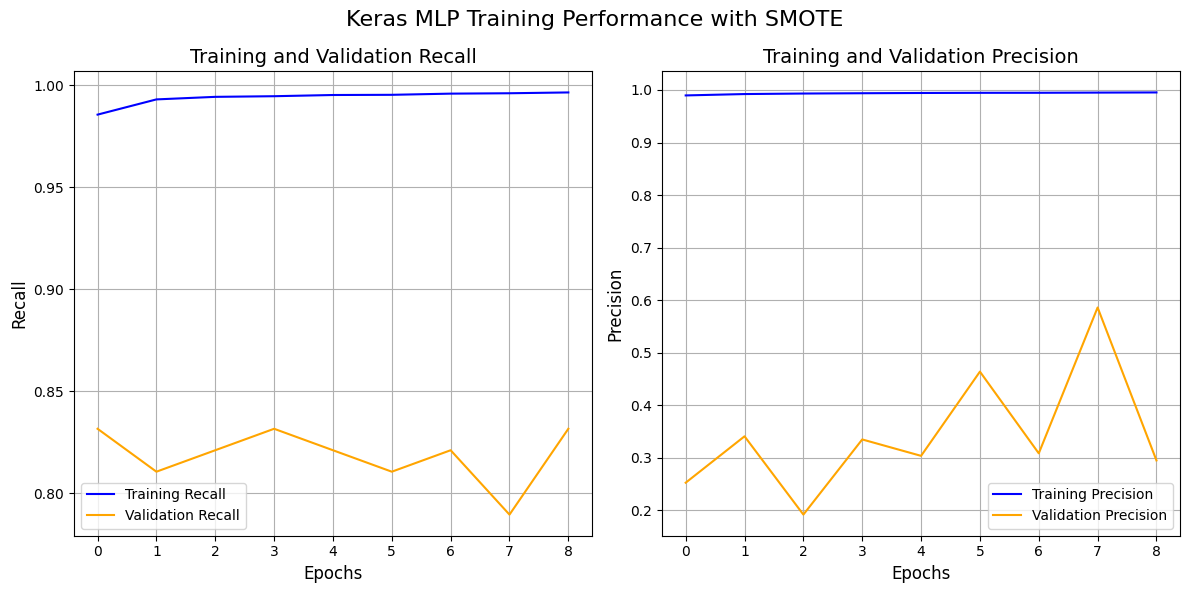

In [ ]:
plt.figure(figsize=(12, 6))

# Plot Training and Validation Recall
plt.subplot(1, 2, 1)
plt.plot(mod_history.history['recall'], label='Training Recall', color='blue')
plt.plot(mod_history.history['val_recall'], label='Validation Recall', color='orange')
plt.title('Training and Validation Recall', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.legend()
plt.grid(True)

# Plot Training and Validation Precision
plt.subplot(1, 2, 2)
plt.plot(mod_history.history['precision'], label='Training Precision', color='blue')
plt.plot(mod_history.history['val_precision'], label='Validation Precision', color='orange')
plt.title('Training and Validation Precision', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend()
plt.grid(True)

plt.suptitle("Keras MLP Training Performance with SMOTE", fontsize=16)
plt.tight_layout()
plt.show()